In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
import requests


In [2]:
airnow_df = pd.read_excel("../data/AirData_Final.xlsx")

In [3]:
census = pd.read_excel('../data/Census.xlsx')
census

,city,state,area_miles,year,population,density,city_state
0,Atlanta,GA,3657.47,2020,5803000,1586.62,"Atlanta, GA"
1,Atlanta,GA,3657.47,2021,5911000,1616.14,"Atlanta, GA"
2,Atlanta,GA,3657.47,2022,6013000,1644.03,"Atlanta, GA"
3,Atlanta,GA,3657.47,2023,6106000,1669.46,"Atlanta, GA"
4,Atlanta,GA,3657.47,2024,6193000,1693.25,"Atlanta, GA"
...,...,...,...,...,...,...,...
85,Jackson,MS,639.64,2020,420000,656.62,"Jackson, MS"
86,Jackson,MS,639.64,2021,426000,666.00,"Jackson, MS"
87,Jackson,MS,639.64,2022,431000,673.82,"Jackson, MS"
88,Jackson,MS,639.64,2023,436000,681.63,"Jackson, MS"


In [4]:
pd.set_option('display.max_columns',None)

In [5]:
aqi_annual = airnow_df.groupby(['reporting_area','state_code','year'])['AQI'].mean().reset_index()
aqi_annual

,reporting_area,state_code,year,AQI
0,Aiken-Augusta - SC and GA,SC,2021,59.500000
1,Aiken-Augusta - SC and GA,SC,2022,54.000000
2,Aiken-Augusta - SC and GA,SC,2023,57.916667
3,Aiken-Augusta - SC and GA,SC,2024,61.166667
4,Alba,MO,2019,35.666667
...,...,...,...,...
941,Yancey County,NC,2020,46.333333
942,Yancey County,NC,2021,55.000000
943,Yancey County,NC,2022,52.750000
944,Yancey County,NC,2023,52.500000


In [6]:
aqi_annual.loc[:, 'AQI'] = airnow_df['AQI'].round().astype('Int64')
aqi_annual

,reporting_area,state_code,year,AQI
0,Aiken-Augusta - SC and GA,SC,2021,42.0
1,Aiken-Augusta - SC and GA,SC,2022,41.0
2,Aiken-Augusta - SC and GA,SC,2023,28.0
3,Aiken-Augusta - SC and GA,SC,2024,36.0
4,Alba,MO,2019,51.0
...,...,...,...,...
941,Yancey County,NC,2020,35.0
942,Yancey County,NC,2021,55.0
943,Yancey County,NC,2022,68.0
944,Yancey County,NC,2023,35.0


In [7]:
final_df = pd.merge(aqi_annual, census, left_on=['reporting_area','state_code','year'],right_on= ['city','state','year'], how="inner")

In [8]:
final_df.to_excel("../data/aqi_census.xlsx", index=False)

In [9]:
final_df.head()

,reporting_area,state_code,year,AQI,city,state,area_miles,population,density,city_state
0,Atlanta,GA,2020,58.0,Atlanta,GA,3657.47,5803000,1586.62,"Atlanta, GA"
1,Atlanta,GA,2021,53.0,Atlanta,GA,3657.47,5911000,1616.14,"Atlanta, GA"
2,Atlanta,GA,2022,33.0,Atlanta,GA,3657.47,6013000,1644.03,"Atlanta, GA"
3,Atlanta,GA,2023,38.0,Atlanta,GA,3657.47,6106000,1669.46,"Atlanta, GA"
4,Atlanta,GA,2024,38.0,Atlanta,GA,3657.47,6193000,1693.25,"Atlanta, GA"


In [10]:
final_df.shape

(90, 10)

In [11]:
numeric_cols = ['population','density','area_miles','AQI']
df_numeric = final_df[numeric_cols]
df_numeric

,population,density,area_miles,AQI
0,5803000,1586.62,3657.47,58.0
1,5911000,1616.14,3657.47,53.0
2,6013000,1644.03,3657.47,33.0
3,6106000,1669.46,3657.47,38.0
4,6193000,1693.25,3657.47,38.0
...,...,...,...,...
85,669000,1817.84,368.02,35.0
86,672000,1825.99,368.02,35.0
87,676000,1836.86,368.02,35.0
88,680000,1847.73,368.02,40.0


In [12]:
corr_matrix = df_numeric.corr()
corr_matrix

,population,density,area_miles,AQI
population,1.000000,0.517265,0.841634,0.026198
density,0.517265,1.000000,0.116374,-0.255831
area_miles,0.841634,0.116374,1.000000,0.269617
AQI,0.026198,-0.255831,0.269617,1.000000


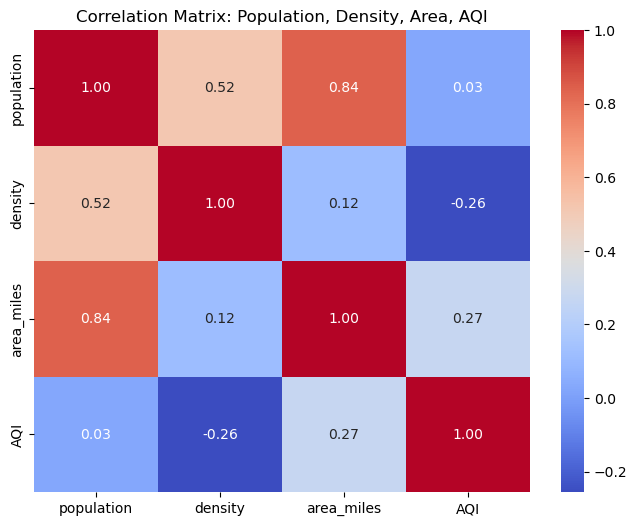

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix: Population, Density, Area, AQI")
plt.savefig("heatmap_aqi.png", dpi=300, bbox_inches='tight') 
plt.show()# High resolution for presentations
plt.close()

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd

# Correlation matrix
corr_matrix = pd.DataFrame({
    'population': [1.000000, 0.517265, 0.841634, 0.026198],
    'density': [0.517265, 1.000000, 0.116374, -0.255831],
    'area_miles': [0.841634, 0.116374, 1.000000, 0.269617],
    'AQI': [0.026198, -0.255831, 0.269617, 1.000000]
}, index=['population', 'density', 'area_miles', 'AQI'])

# Green-to-yellow colormap
cmap = mcolors.LinearSegmentedColormap.from_list("green_yellow", ["green", "yellow"])

# Create figure and axes with transparent background
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)      # figure background transparent
ax.patch.set_alpha(0)       # axes background transparent

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap, center=0,
            linewidths=0.5, linecolor='gray', ax=ax)

plt.title("Correlation Matrix: Population, Density, Area, AQI", fontsize=14)

# Save figure with transparent background
plt.savefig("heatmap_aqi_transparent.png", dpi=300, bbox_inches='tight', transparent=True)
plt.close()


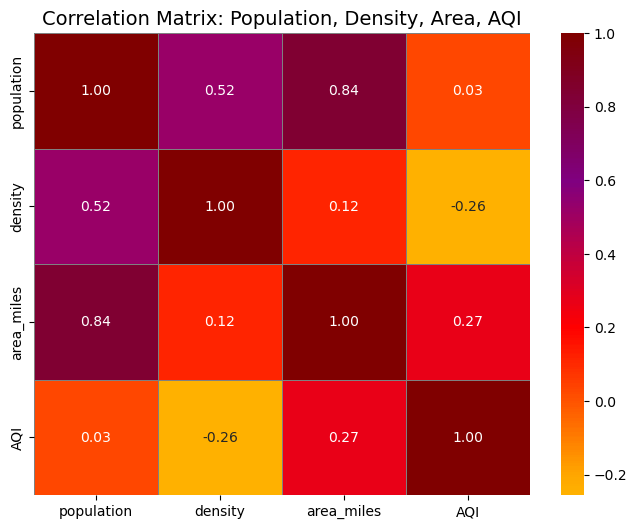

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# Your correlation matrix
corr_matrix = pd.DataFrame({
    'population': [1.000000, 0.517265, 0.841634, 0.026198],
    'density': [0.517265, 1.000000, 0.116374, -0.255831],
    'area_miles': [0.841634, 0.116374, 1.000000, 0.269617],
    'AQI': [0.026198, -0.255831, 0.269617, 1.000000]
}, index=['population', 'density', 'area_miles', 'AQI'])

# Define a diverging colormap with AQI-inspired colors
colors = ['green', 'yellow', 'orange', 'red', 'purple', 'maroon']
cmap = mcolors.LinearSegmentedColormap.from_list('aqi_corr', colors, N=256)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap, center=0, linewidths=0.5, linecolor='gray')
plt.title("Correlation Matrix: Population, Density, Area, AQI", fontsize=14)
plt.show()

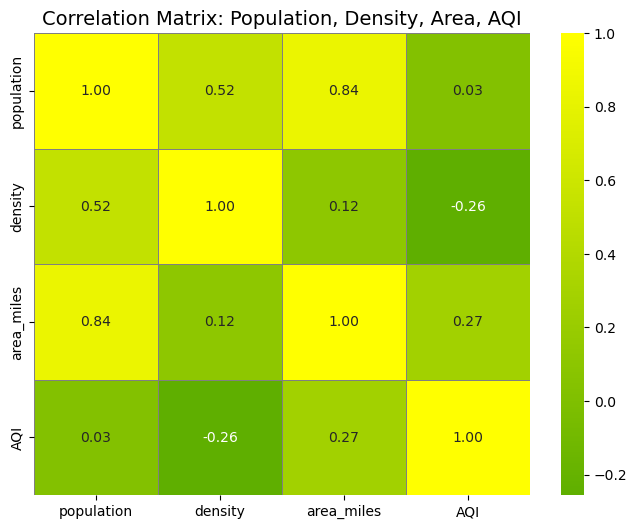

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd

# Your correlation matrix
corr_matrix = pd.DataFrame({
    'population': [1.000000, 0.517265, 0.841634, 0.026198],
    'density': [0.517265, 1.000000, 0.116374, -0.255831],
    'area_miles': [0.841634, 0.116374, 1.000000, 0.269617],
    'AQI': [0.026198, -0.255831, 0.269617, 1.000000]
}, index=['population', 'density', 'area_miles', 'AQI'])

# Create a green-to-yellow colormap
cmap = mcolors.LinearSegmentedColormap.from_list("green_yellow", ["green", "yellow"])

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap, center=0, linewidths=0.5, linecolor='gray')
plt.title("Correlation Matrix: Population, Density, Area, AQI", fontsize=14)
plt.show()


In [14]:
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Var1','Var2','Correlation']
corr_pairs = corr_pairs[corr_pairs['Var1'] != corr_pairs['Var2']]
corr_pairs

,Var1,Var2,Correlation
1,population,density,0.517265
2,population,area_miles,0.841634
3,population,AQI,0.026198
4,density,population,0.517265
6,density,area_miles,0.116374
7,density,AQI,-0.255831
8,area_miles,population,0.841634
9,area_miles,density,0.116374
11,area_miles,AQI,0.269617
12,AQI,population,0.026198
